In [ ]:
import logging

import carla
import pandas as pd
import numpy as np
import carla_extension
from carla_extension.manager import CarlaSimulatorManager
logging.basicConfig(level=logging.INFO)

In [ ]:

carla_config = carla_extension.CarlaConfig(low_quality_mode=True, waiting_time=20.0)

manager = CarlaSimulatorManager(carla_config)

client = manager.startup()\
                .change_world("Town05_Opt")\
                .client

In [ ]:

client.reload_world()

In [ ]:
# 生成车辆

# 设置车型
blueprint_library = client.get_world().get_blueprint_library()
vehicle_bp = blueprint_library.find("vehicle.nissan.micra")

# 位置
# 初始点(朝北,270度)
spawn_point = carla.Transform(carla.Location(x=-2.34, y=-37.45, z=0.2), carla.Rotation(yaw=270))
# 车位 (朝西, 180度)
end_point = carla.Transform(carla.Location(x=4, y=-30, z=0.1), carla.Rotation(yaw=180))
manager.world = client.get_world()
manager.camera = manager.world.get_spectator()
manager.ego = manager.world.spawn_actor(vehicle_bp, spawn_point)  # type: ignore
manager.camera_follow()
settings = manager.world.get_settings()
settings.fixed_delta_seconds = 0.2
settings.synchronous_mode = True
manager.world.apply_settings(settings)
manager.world.tick()

In [ ]:
manager.camera_follow(False)
manager.world.tick()

In [ ]:
df: pd.DataFrame = pd.read_pickle(
    "D:/Lenovo/Documents/Repositories/research/driving_school/database/middleware/coach_102_transformed/coach_102_RT.pkl")
print(df.info())

## 用 realspeed, gpslog.carla, carangle.carla, 计算出速度在 carla 坐标系下 x, y的分量

### 然后应用 set_target_velocity

In [ ]:
def get_carla_speed(df: pd.DataFrame) -> list[carla.Vector3D]:
    angle: np.ndarray = df["carangle.carla"]
    speed: np.ndarray = df["realspeed"].reshape(-1)
    gear: np.ndarray = df["gear"].reshape(-1)
    gear = np.sign(gear)

    angle = np.where(gear < 0, angle, angle - 180)
    # 计算速度在 carla 坐标系下的分量
    rad = np.deg2rad(angle)
    vx = speed * np.cos(rad)
    vy = speed * np.sin(rad)
    return [carla.Vector3D(x=x, y=y, z=0.0) for x, y in zip(vx, vy)]


def transform_speed_to_direction(speed: float, rotation: carla.Rotation) -> carla.Vector3D:
    """给定速度大小, 给定车辆朝向, 计算该朝向大小为 speed 的速度向量"""
    yaw_rad = np.deg2rad(rotation.yaw)
    x = np.cos(yaw_rad) * speed
    y = np.sin(yaw_rad) * speed
    z = 0.0
    return carla.Vector3D(x, y, z)

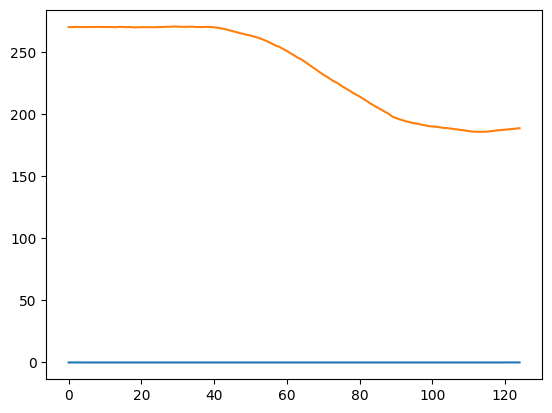

In [17]:
import random
import matplotlib.pyplot as plt
index = random.randint(0, len(df) - 1)
throttle: np.ndarray = df.iloc[index]["acceleratangle"] / 100
plt.plot(throttle)
steer: np.ndarray = -df.iloc[index]["steeringangle"] / 600
brake: np.ndarray = df.iloc[index]["brakeangle"] / 100
reverse: np.ndarray = df.iloc[index]["gear"]
reverse = -np.sign(reverse)
reverse = np.clip(reverse, 0, 1)


speed = df.iloc[index]["realspeed"].reshape(-1) / 3.6   # 速度(绝对值)
should_r = np.sign(df.iloc[index]["gear"].reshape(-1))
speed = speed * should_r  # 速度(带方向)

#
xyz: np.ndarray = df.iloc[index]["gpslog.carla"]
angle: np.ndarray = df.iloc[index]["carangle.carla"]
plt.plot(angle)

gear: np.ndarray = df.iloc[index]["gear"]
gear[gear < 0] = 1

for i in range(10):
    manager.ego.set_transform(spawn_point)
    manager.ego.apply_control(carla.VehicleControl(0, 0, 1, True))
    manager.camera_follow(False)
    manager.world.tick()

# 应用
# for t, s, b, r, g in zip(throttle, steer, brake, reverse, gear):
#     print(f"throttle: {t}, steer: {s}, brake: {b}, reverse: {r}, gear: {g}")
#     control = carla.VehicleControl(
#         throttle=t.item(),
#         steer=s.item(),
#         brake=b.item(),
#         reverse=bool(r.item()),
#         manual_gear_shift=True,
#         gear=int(g.item())
#     )
#     assert manager.ego is not None
#     manager.ego.apply_control(control)
#     manager.camera_follow(False)
#     manager.world.tick()

v_list = get_carla_speed(df.iloc[index])
assert manager.ego is not None
for v, r in zip(v_list, angle):
    tr = manager.ego.get_transform()
    tr.rotation.yaw = r
    manager.ego.set_transform(tr)
    manager.ego.set_target_velocity(v)

    manager.camera_follow(False)
    manager.world.tick()


# for xyz_p, angle_p in zip(xyz, angle):
#     # print(xyz_p.shape, angle_p.shape)
#     trans = carla.Transform(
#         carla.Location(x=xyz_p[0], y=xyz_p[1], z=0.2),
#         carla.Rotation(yaw=angle_p)
#     )
#     assert manager.ego is not None
#     manager.ego.set_transform(trans)
#     manager.camera_follow(False)
#     manager.world.tick()

# 混合 方向盘 + speed
# 朝向 + speed
# v_list = get_carla_speed(df.iloc[index])
# for t, s, b, r, g, v, a in zip(throttle, steer, brake, reverse, gear, speed, angle):
#     print(f"throttle: {t.item():.2f}, steer: {s.item():.2f}, brake: {b.item():.2f}, reverse: {r.item()}, gear: {g.item()}, speed: {v.item():.2f} m/s")
#     control = carla.VehicleControl(
#         throttle=t.item(),
#         steer=s.item(),
#         brake=b.item(),
#         reverse=bool(r.item()),
#         manual_gear_shift=True,
#         gear=int(g.item())
#     )
#     assert manager.ego is not None
#     v = transform_speed_to_direction(v.item(), manager.ego.get_transform().rotation)
#     trans = manager.ego.get_transform()
#     trans.rotation.yaw = a

#     # manager.ego.apply_control(control)
#     manager.ego.set_target_velocity(v)
#     manager.ego.set_transform(trans)
#     manager.camera_follow(False)
#     manager.world.tick()

In [ ]:
df.iloc[0:1]

In [ ]:
import pandas as pd
import numpy as np

df2: pd.DataFrame = pd.read_pickle("./test_pendulum.pkl")


def draw_polyline_on_world(client: carla.Client, locations: np.ndarray,
                           color=(255, 0, 0), thickness: float = 0.08, life_time: float = 0.0):
    """
    在 Carla 世界中用 debug 绘制折线（locations: (L,3) -> (x,y,z)）。
    - client: carla.Client 实例
    - locations: np.ndarray (L,3)
    - color: (r,g,b)
    - thickness: 线粗细（draw_line 的 thickness）
    - life_time: 显示时间（秒），0.0 表示持久
    """
    world = client.get_world()
    locs = np.asarray(locations, dtype=float)
    locs[:, -1] = 0.5
    if locs.ndim != 2 or locs.shape[1] != 3:
        raise ValueError("locations must be shape (L,3)")

    col = carla.Color(int(color[0]), int(color[1]), int(color[2]), 127)

    if locs.shape[0] == 1:
        world.debug.draw_point(carla.Location(x=locs[0, 0], y=locs[0, 1], z=0.15),
                               size=thickness, color=col, life_time=life_time)
        return

    for p0, p1 in zip(locs[:-1], locs[1:]):
        a = carla.Location(x=float(p0[0]), y=float(p0[1]), z=float(p0[2]))
        b = carla.Location(x=float(p1[0]), y=float(p1[1]), z=float(p1[2]))
        world.debug.draw_line(a, b, thickness=thickness, color=col, life_time=life_time)


for index, row in df2.iterrows():
    location = row["gpslog.carla"]  # (L,3) numpy array
    yaw = row["carangle.carla"]          # 可选：如果需要可用 yaw 做颜色/标注
    draw_polyline_on_world(client, location, color=(255, 0, 0), thickness=0.06, life_time=0)
client.get_world().tick()

In [ ]:
client.get_world().tick()

In [ ]:
df2.iloc[0:1]

In [ ]:
client.reload_world()

In [ ]:
## 模仿的源数据

## 模仿的源数据

## 现有的论文 专家的数据怎么使用?

# 1. RL 的做法, 如何结合专家数据(IRL, GAIL)

# 2. BC 源域和目标域不一样